# Notes

The `pem` files are in `ASN.1` format with `DER` encoding which is basiacally `tag,length,value`

This is the offical [RSA](https://www.rfc-editor.org/rfc/rfc8017) Private Key sequence 

```
      RSAPrivateKey ::= SEQUENCE {
          version           Version,
          modulus           INTEGER,  -- n
          publicExponent    INTEGER,  -- e
          privateExponent   INTEGER,  -- d
          prime1            INTEGER,  -- p
          prime2            INTEGER,  -- q
          exponent1         INTEGER,  -- d mod (p-1)
          exponent2         INTEGER,  -- d mod (q-1)
          coefficient       INTEGER,  -- (inverse of q) mod p
          otherPrimeInfos   OtherPrimeInfos OPTIONAL
      }
```

```
   o  version is the version number, for compatibility with future
      revisions of this document.  It SHALL be 0 for this version of the
      document, unless multi-prime is used; in which case, it SHALL be
      1.

            Version ::= INTEGER { two-prime(0), multi(1) }
               (CONSTRAINED BY
               {-- version must be multi if otherPrimeInfos present --})
   o  modulus is the RSA modulus n.
   o  publicExponent is the RSA public exponent e.
   o  privateExponent is the RSA private exponent d.
   o  prime1 is the prime factor p of n.
   o  prime2 is the prime factor q of n.
   o  exponent1 is d mod (p - 1).
   o  exponent2 is d mod (q - 1).
   o  coefficient is the CRT coefficient q^(-1) mod p.
```

However, there are two differences between RSA [Formats](https://stackoverflow.com/questions/20065304/differences-between-begin-rsa-private-key-and-begin-private-key):

- `BEGIN PRIVATE KEY` -> PKCS#8 just base64 encoded 
- `BEGIN RSA PRIVATE KEY` -> PKCS#1 which maps to the above DER ASN.1 sequence

In [1]:
from base64 import b64decode

from asn1 import Decoder,Encoder
import asn1
from Crypto.Util.number import long_to_bytes,bytes_to_long

In [21]:
data1 = b64decode(
r"""
MIIJJwIBAAKCAgEAhbIueAz0eErBWcRu9aNkArpuAwtysp3egIzD+dqGpSLWPIm+
HLP8gIBK2wAVXXgqLYqq4ozUslmxhy1u0BfPzla/gmj0AZAEL1DtGiMenKU5a16J
oP2pkCcXpK6BV3alEg97yGU4TN3Fj9RysLlQGUC+xF37iit4YlFPk3TFlJK3TWMe
IAj21MdDh00XzP1r198l8NZSXEuCuKaM16m40H93QQpnVnW/Feo3rq6t/SS0dmbz
RiTTdF9kFBlTQToc8PnQOmdBgy+AdM891lLgQUygjcOYGPFfpEwlDtjTH7e0KiMX
j8i7fMy6p2hvon6JSJ+p7jyBidj7hveEMDFe2EHWLbHkfAze5pX3qlXmXzD4lEyQ
zwrRFIVIrWWiuQyCo5ivNGNAyepfl7BMNKmBc4roE83pNch02q6oU5Fl2VFiGJZQ
cImPO6Uy60/NFbUozAdllwuw/WywlKemno9mxPJSfrB+Z5n5NZbU5/kHye/v8gh3
+uUGbEfaJZlP4TqE/QlS2AVaojju5Uwdkbjzn+Rixzs4dzQYuRU93Qd/Zu5rLeUv
ftgCjRO9bIFJ2Cr7dwKPuwetwxDBGR8dgd0xorodajEKCvm5CRC/7MM4igsALTUP
ptjcpSihDp6NzvcNJa8wmKC4wB00Rvj4NJscd4GQckEK9OSLUMxtGlDVBj8CAwEA
AQ
""" + "=="
)

data2 = b64decode(
r"""
AoIBAH7MSLvBg7UmdC0mCMuRBVO+V6/9yWbBsSgMDteqgJrSPRGlAx8hp5Lg
+XNlZ/b78AoSYRGkt7A1y0t63hXWnZtLLtnb9+vhlV7kei1TPEIxqOMDryFeGGJx
ev3pOr5ghjdFp2jqO/PCLRmQ2OY3eKyqy+W4v9hy9lkasZec/1AI9X/TrLIYcjgI
Mav1kTyjuZiN5xM2h1mnResjl8B0m4nEokZZ+WckE3OsqpCYf9Y6eXFnKnInkZ92
ygwtNYCFAzIfs6YonY6Fm6DtYiei+1MtC/CXhmUbsA3zLJZAgA6JdIiJaV2O5jPJ
ApxJ1OpLoMQ/10knSR76EJBhK2I8LHs
""" + "=="
)


In [22]:
fields = [
"version",
"modulus",
"publicExponent",
"privateExponent",
"prime1",
"prime2",
"exponent1",
"exponent2",
"coefficient",
"otherPrimeInfos",
]

In [23]:
decoder = Decoder()
decoder.start(data1)

tag = decoder.peek()
print(tag)
decoder.enter()

rsa = dict()

for field in fields:
    try:
        tag,value = decoder.read()
        rsa[field] = value
        print(tag)
    except Exception as e:
        print(e)
        break

rsa

Tag(nr=<Numbers.Sequence: 0x10>, typ=<Types.Constructed: 0x20>, cls=<Classes.Universal: 0x00>)
Tag(nr=<Numbers.Integer: 0x02>, typ=<Types.Primitive: 0x00>, cls=<Classes.Universal: 0x00>)
Tag(nr=<Numbers.Integer: 0x02>, typ=<Types.Primitive: 0x00>, cls=<Classes.Universal: 0x00>)
Tag(nr=<Numbers.Integer: 0x02>, typ=<Types.Primitive: 0x00>, cls=<Classes.Universal: 0x00>)
None
None
None
None
None
None
None


{'version': 0,
 'modulus': 5454321812746169333570136249381804529280309269761313127036558213136405511950118234017895604046109413101684565332311019331467140375628063090267724986319238263499480998114349040990237753419799317228614098348362013924290012464181224045652333927876008433555473057840976186721433468095347354501521482895108645059524562352422830141661848715527252259297906458057443699248082580590018105594815424135519881366737500266489938237365490009327215409064776017391022890486364497913121125115044883257048735567108449779331321859168096778459026638220025355694372321996758832314142580526130143676025909347993247842406200453656294358055552280311636263927900286680282882153380676965723940542649728706586396698661429050789224968522925842349575211623720297627357834457003859639345111042864591655533339982684759399676091866736282634337760891964837049887759196196943665485424006926477951971858862338289483716825570998272359796137204706432116512768294756423177784382469117812077064040891910309481587

In [43]:
decoder = Decoder()
decoder.start(data2)

tag,value = decoder.read()
# Let's just guess what the last value could be, I am guessing prime1/prime2 
assert rsa["modulus"] % value == 0, "Its not prime1 or prime2"

AssertionError: Its not prime1 or prime2

In [ ]:
decoder = Decoder()
decoder.start(data2[:1])

tag,value = decoder.read()
# Let's just guess what the last value could be, I am guessing prime1/prime2 
assert rsa["modulus"] % value == 0, "Its not prime1 or prime2"

Error: ASN1 decoding error: premature end of input.

In [26]:
decoder = Decoder()
decoder.start(data2)

tag = decoder.peek()
assert tag.nr == asn1.Numbers.Integer

# the length is 256, meaning that we have two length bytes, one tag byte => 259 bytes only used :(

decoder._decode_length(tag.typ),len(data2)

(256, 260)

In [41]:
import Crypto.PublicKey.RSA as RSA
from Crypto.Cipher import PKCS1_v1_5

In [81]:
for i in range(-100000,100000):
    if rsa['modulus'] % (i+value) == 0:
        print(i) 

In [39]:
# Lets calc bit lengths

items = [
    (0//8, "header"),
    (4096//8, "mod"),
    (17//8, "e "),
    (4091//8, "d"),
    (2048//8, "p"),
    (2048//8, "q"),
    (2048//8, "d_q"),
    (2048//8, "d_p"),
    (2048//8, "coeff"),
]
last = 1
for item in items:
    bitlen_a,v_a = item
    mod = 4/3
    print(last * mod ,v_a,(last + bitlen_a + bitlen_a/128 + 1)*mod)
    #                        length decoding-tag-next byte
    last = last + bitlen_a + bitlen_a/128 + 1 + 1

1.3333333333333333 header 2.6666666666666665
4.0 mod 693.3333333333333
694.6666666666666 e  698.6875
700.0208333333333 d 1388.0104166666665
1389.34375 p 1734.6770833333333
1736.0104166666665 q 2081.34375
2082.677083333333 d_q 2428.0104166666665
2429.34375 d_p 2774.677083333333
2776.0104166666665 coeff 3121.34375


In [37]:
# its quite certain that d_p or d_q is given
rsa["exponent1"] = value
rsa

{'version': 0,
 'modulus': 5454321812746169333570136249381804529280309269761313127036558213136405511950118234017895604046109413101684565332311019331467140375628063090267724986319238263499480998114349040990237753419799317228614098348362013924290012464181224045652333927876008433555473057840976186721433468095347354501521482895108645059524562352422830141661848715527252259297906458057443699248082580590018105594815424135519881366737500266489938237365490009327215409064776017391022890486364497913121125115044883257048735567108449779331321859168096778459026638220025355694372321996758832314142580526130143676025909347993247842406200453656294358055552280311636263927900286680282882153380676965723940542649728706586396698661429050789224968522925842349575211623720297627357834457003859639345111042864591655533339982684759399676091866736282634337760891964837049887759196196943665485424006926477951971858862338289483716825570998272359796137204706432116512768294756423177784382469117812077064040891910309481587

# other idea; It could be the coefficient but likely not due to the bytesizes

[Solution](https://crypto.stackexchange.com/questions/46486/rsa-given-n-e-dp-is-it-possible-to-find-d)

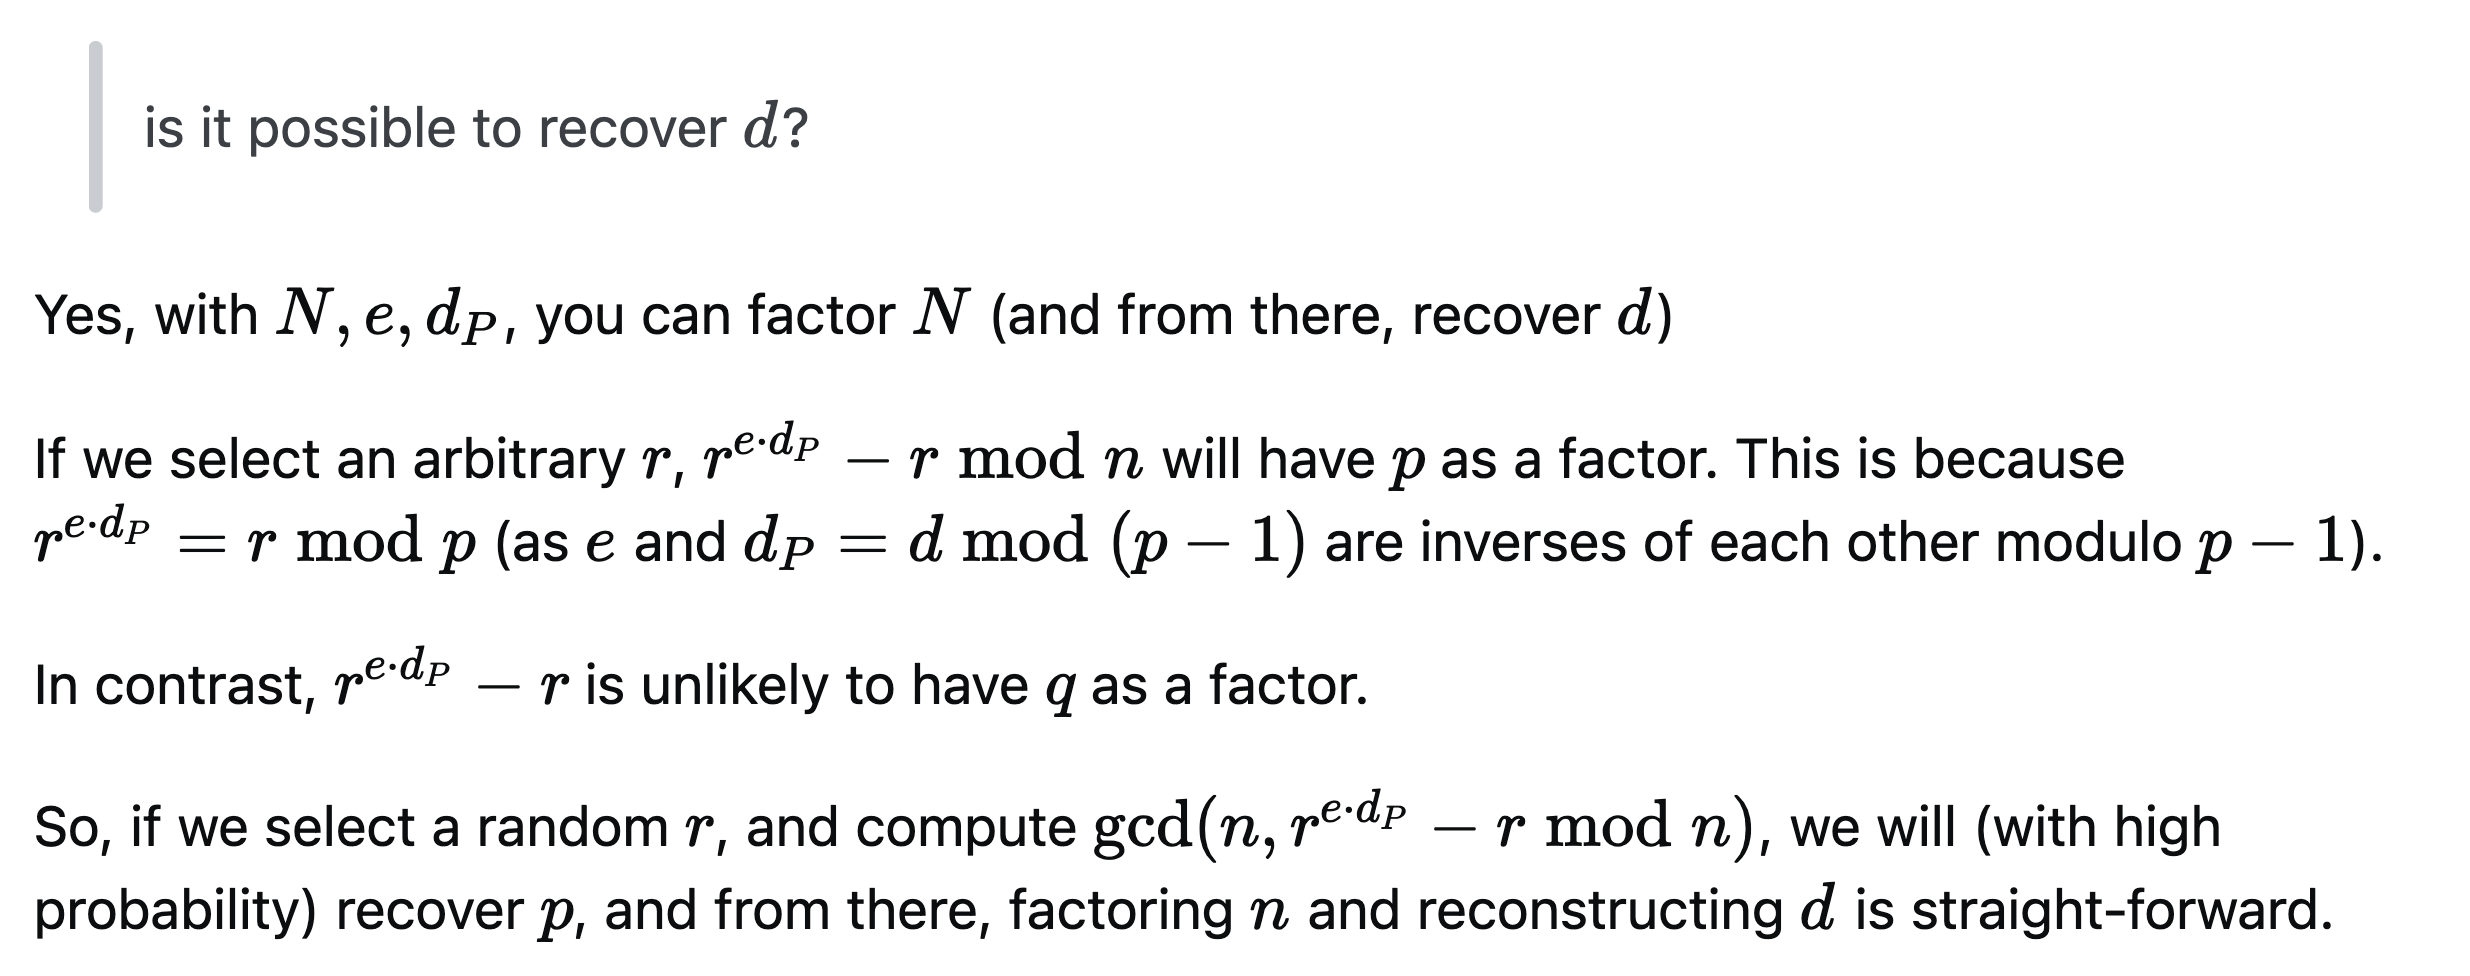

In [46]:
import random
import math 


r = random.randint(1,rsa["modulus"])
q = math.gcd(
    pow(r,rsa["publicExponent"] * rsa["exponent1"],rsa["modulus"]) - r,rsa["modulus"]
)

assert rsa["modulus"] % q == 0

In [49]:
from Crypto.PublicKey import RSA
from Crypto.Cipher import PKCS1_v1_5

p = rsa["modulus"]//q
d = pow(rsa["publicExponent"],-1,(p-1)*(q-1))

key = RSA.construct(
    (rsa["modulus"],rsa["publicExponent"],d)
)

with open("encrypted.txt","rb") as f:
    print(
        PKCS1_v1_5.new(key).decrypt(f.read(),None)
    )

bytearray(b'CTF{rsa_attacks_usually_involves_modulo_arithmetic}')
